In [1]:
import pandas as pd
from pathlib import Path
import numpy as np

data_path = Path.cwd().parent / 'User_features.csv'
df = pd.read_csv(data_path, index_col='user_id')

# 基本情况
print(df.shape)        # 应该是 (98万, 20列左右)
print(df.dtypes)
print(df.head())
print(df.describe())

(983847, 19)
pv_count             int64
fav_count            int64
cart_count           int64
buy_count            int64
total_count          int64
pv_ratio           float64
fav_ratio          float64
cart_ratio         float64
buy_ratio          float64
cart_per_pv        float64
buy_per_cart       float64
buy_per_pv         float64
buy_per_fav        float64
active_days          int64
morning_ratio      float64
afternoon_ratio    float64
evening_ratio      float64
midnight_ratio     float64
funnel_depth         int64
dtype: object
         pv_count  fav_count  cart_count  buy_count  total_count  pv_ratio  \
user_id                                                                      
1              49          0           0          0           49  1.000000   
2              38          7           0          7           52  0.730769   
3              30          5          15          0           50  0.600000   
4             262          0          13          4          279  0.93

In [2]:
# ==============================
# 第二阶段：预处理
# ==============================

# Step 1: 填充 NaN（分母为0的转化率视为0）
df['buy_per_cart'] = df['buy_per_cart'].fillna(0)
df['buy_per_fav']  = df['buy_per_fav'].fillna(0)

print("NaN检查：", df.isnull().sum().sum())  # 应为 0

# Step 2: 截断异常转化率（clip到99分位数）
ratio_cols = ['cart_per_pv', 'buy_per_cart', 'buy_per_pv', 'buy_per_fav']

for col in ratio_cols:
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper)
    print(f"{col} 截断上限: {upper:.4f}")

# Step 3: 对频次类特征做 log1p 变换
count_cols = ['pv_count', 'fav_count', 'cart_count', 'buy_count',
              'total_count', 'active_days']

for col in count_cols:
    df[f'{col}_log'] = np.log1p(df[col])

# Step 4: 确认最终用于聚类的特征列
feature_cols = [
    # 频次（log变换后）
    'pv_count_log', 'fav_count_log', 'cart_count_log', 'buy_count_log',
    # 行为比例
    'pv_ratio', 'fav_ratio', 'cart_ratio', 'buy_ratio',
    # 转化漏斗
    'cart_per_pv', 'buy_per_cart', 'buy_per_pv', 'buy_per_fav',
    # 活跃时间
    'active_days_log',
    'morning_ratio', 'afternoon_ratio', 'evening_ratio', 'midnight_ratio',
    # 漏斗深度
    'funnel_depth'
]

X = df[feature_cols].copy()
print(f"\n特征矩阵形状: {X.shape}")
print(X.describe().round(3))


NaN检查： 0
cart_per_pv 截断上限: 0.5217
buy_per_cart 截断上限: 4.5000
buy_per_pv 截断上限: 0.3500
buy_per_fav 截断上限: 5.0000

特征矩阵形状: (983847, 18)
       pv_count_log  fav_count_log  cart_count_log  buy_count_log    pv_ratio  \
count    983847.000     983847.000      983847.000     983847.000  983847.000   
mean          3.988          0.605           1.241          0.756       0.883   
std           0.946          0.942           1.016          0.697       0.099   
min           0.693          0.000           0.000          0.000       0.003   
25%           3.367          0.000           0.000          0.000       0.840   
50%           4.060          0.000           1.099          0.693       0.905   
75%           4.682          1.099           2.079          1.099       0.951   
max           6.676          5.943           5.030          5.568       1.000   

        fav_ratio  cart_ratio   buy_ratio  cart_per_pv  buy_per_cart  \
count  983847.000  983847.000  983847.000   983847.000    983847.00

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 验证标准化结果
print(f"标准化后形状: {X_scaled.shape}")
print(f"各特征均值（应接近0）:\n {X_scaled.mean(axis=0).round(3)}")
print(f"各特征标准差（应接近1）:\n {X_scaled.std(axis=0).round(3)}")


标准化后形状: (983847, 18)
各特征均值（应接近0）:
 [ 0. -0. -0. -0. -0. -0.  0. -0.  0.  0.  0.  0.  0. -0.  0. -0. -0.  0.]
各特征标准差（应接近1）:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [4]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

# 累计方差解释率
cumvar = np.cumsum(pca.explained_variance_ratio_)
for i, v in enumerate(cumvar):
    print(f"PC{i+1}: {pca.explained_variance_ratio_[i]:.4f}  累计: {v:.4f}")

PC1: 0.2141  累计: 0.2141
PC2: 0.1507  累计: 0.3647
PC3: 0.1428  累计: 0.5075
PC4: 0.1061  累计: 0.6136
PC5: 0.0892  累计: 0.7028
PC6: 0.0710  累计: 0.7738
PC7: 0.0613  累计: 0.8351
PC8: 0.0470  累计: 0.8821
PC9: 0.0372  累计: 0.9193
PC10: 0.0286  累计: 0.9479
PC11: 0.0193  累计: 0.9672
PC12: 0.0120  累计: 0.9791
PC13: 0.0112  累计: 0.9903
PC14: 0.0060  累计: 0.9964
PC15: 0.0025  累计: 0.9989
PC16: 0.0011  累计: 1.0000
PC17: 0.0000  累计: 1.0000
PC18: 0.0000  累计: 1.0000


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    print(f"正在计算 K={k}...")
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    silhouette_scores.append(sil)
    print(f"  K={k}  Inertia={km.inertia_:.0f}  Silhouette={sil:.4f}")

正在计算 K=2...
  K=2  Inertia=15431882  Silhouette=0.1310
正在计算 K=3...
  K=3  Inertia=13862770  Silhouette=0.1281
正在计算 K=4...
  K=4  Inertia=12613619  Silhouette=0.1383
正在计算 K=5...
  K=5  Inertia=11618773  Silhouette=0.1440
正在计算 K=6...
  K=6  Inertia=10929025  Silhouette=0.1512
正在计算 K=7...
  K=7  Inertia=10336799  Silhouette=0.1362
正在计算 K=8...
  K=8  Inertia=9908777  Silhouette=0.1401
正在计算 K=9...
  K=9  Inertia=9503262  Silhouette=0.1319


In [6]:
km_final = KMeans(n_clusters=6, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print(df['cluster'].value_counts().sort_index())

cluster
0    215893
1     64697
2    147436
3    114862
4     66492
5    374467
Name: count, dtype: int64


In [7]:
# 各簇核心特征均值对比
profile_cols = [
    'pv_count', 'fav_count', 'cart_count', 'buy_count',
    'pv_ratio', 'fav_ratio', 'cart_ratio', 'buy_ratio',
    'cart_per_pv', 'buy_per_cart', 'buy_per_pv',
    'active_days', 'funnel_depth',
    'morning_ratio', 'afternoon_ratio', 'evening_ratio', 'midnight_ratio'
]

cluster_profile = df.groupby('cluster')[profile_cols].mean().round(3)
print(cluster_profile.T)  # 转置，每列是一个簇，便于横向对比

cluster               0        1        2       3       4        5
pv_count         39.519  116.636  109.513  43.114  20.822  105.021
fav_count         0.561    2.146   13.194   0.635   0.489    0.452
cart_count        0.707    7.247    3.097  11.136   1.528    6.125
buy_count         0.098    5.090    1.804   1.305   3.941    1.929
pv_ratio          0.961    0.876    0.836   0.754   0.763    0.919
fav_ratio         0.014    0.020    0.122   0.011   0.019    0.004
cart_ratio        0.021    0.054    0.024   0.209   0.053    0.054
buy_ratio         0.004    0.049    0.018   0.026   0.165    0.023
cart_per_pv       0.023    0.065    0.031   0.275   0.077    0.061
buy_per_cart      0.004    1.124    0.428   0.136   1.170    0.442
buy_per_pv        0.005    0.059    0.023   0.037   0.199    0.025
active_days       4.813    7.006    6.649   5.566   4.822    6.752
funnel_depth      2.198    4.000    3.589   3.582   4.000    3.812
morning_ratio     0.315    0.315    0.310   0.309   0.336    0

In [11]:
cluster_names = {
    0: '纯浏览型',
    1: '高价值活跃型',
    2: '收藏研究型',
    3: '加车犹豫型',
    4: '冲动直购型',
    5: '普通活跃型'
}

df['cluster_name'] = df['cluster'].map(cluster_names)

user_labels = df[['cluster', 'cluster_name']].reset_index()
user_labels.columns = ['user_id', 'cluster', 'cluster_name']

print(user_labels.shape)
print(user_labels.head(10))

user_labels.to_csv(Path.cwd().parent /'user_cluster_labels.csv', index=False)
print("已保存至 user_cluster_labels.csv")

(983847, 3)
   user_id  cluster cluster_name
0        1        0         纯浏览型
1        2        4        冲动直购型
2        3        3        加车犹豫型
3        4        5        普通活跃型
4        5        0         纯浏览型
5        6        5        普通活跃型
6        7        5        普通活跃型
7        8        0         纯浏览型
8        9        0         纯浏览型
9       10        0         纯浏览型
已保存至 user_cluster_labels.csv


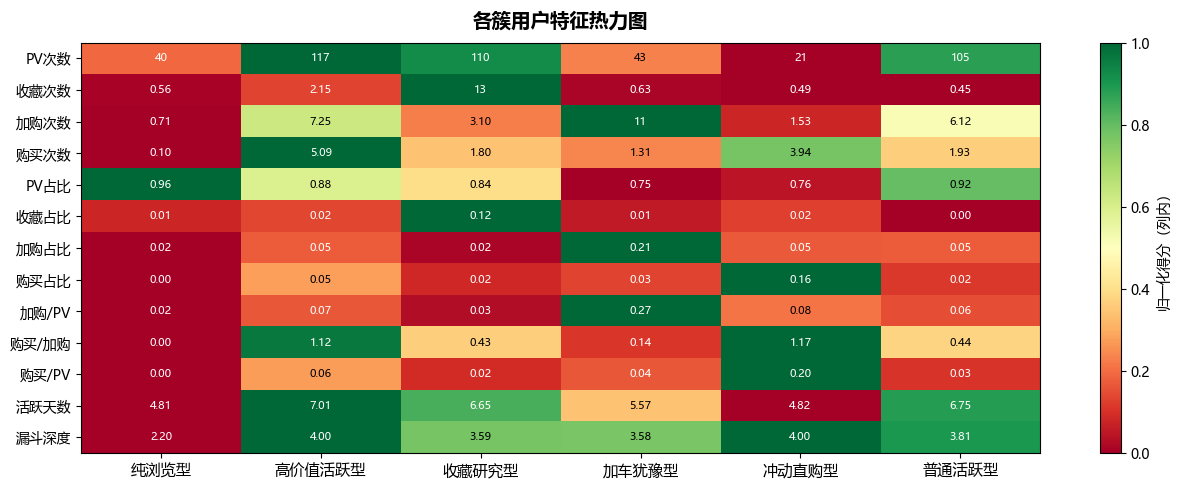

热力图已保存


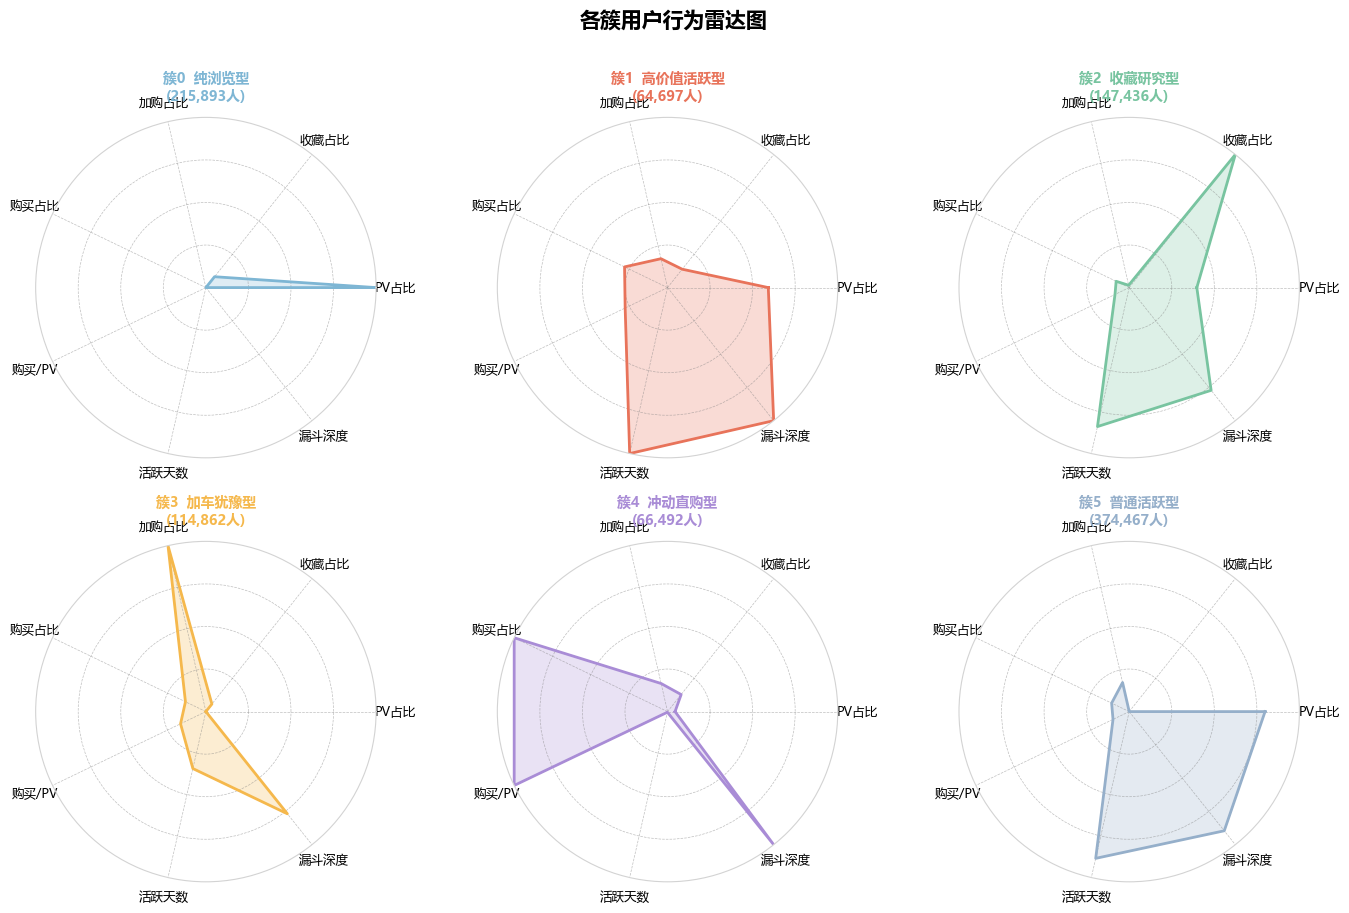

雷达图已保存


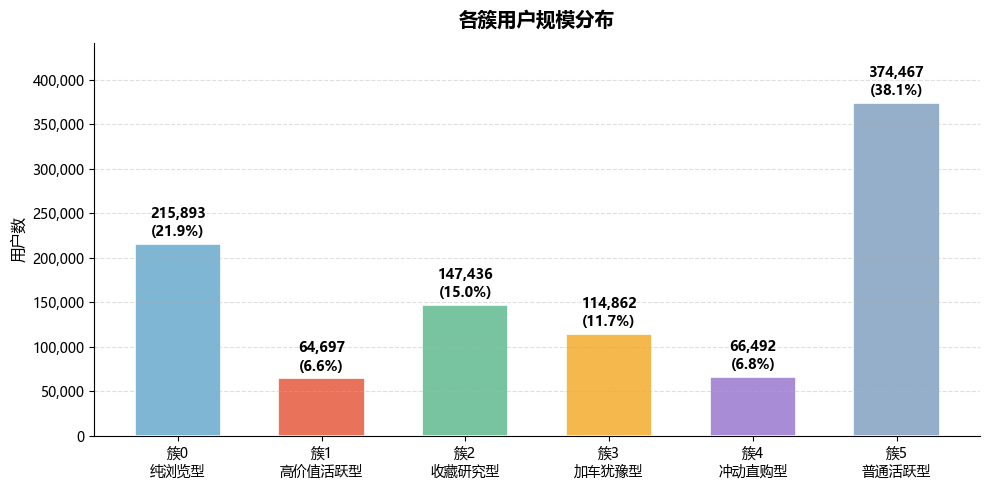

规模分布图已保存


In [9]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False

cluster_names = {
    0: '纯浏览型', 1: '高价值活跃型', 2: '收藏研究型',
    3: '加车犹豫型', 4: '冲动直购型',  5: '普通活跃型'
}
colors = ['#7EB6D4', '#E8735A', '#78C4A0', '#F5B84C', '#A98CD6', '#95AFCA']

# ── 图1：热力图 ──────────────────────────────────────────────
heatmap_cols = [
    'pv_count', 'fav_count', 'cart_count', 'buy_count',
    'pv_ratio', 'fav_ratio', 'cart_ratio', 'buy_ratio',
    'cart_per_pv', 'buy_per_cart', 'buy_per_pv',
    'active_days', 'funnel_depth'
]
col_labels = [
    'PV次数', '收藏次数', '加购次数', '购买次数',
    'PV占比', '收藏占比', '加购占比', '购买占比',
    '加购/PV', '购买/加购', '购买/PV',
    '活跃天数', '漏斗深度'
]

profile = df.groupby('cluster')[heatmap_cols].mean()
# 列归一化（每个特征在0~1之间），便于跨量纲对比
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(profile_norm.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(6))
ax.set_xticklabels([cluster_names[i] for i in range(6)], fontsize=11)
ax.set_yticks(range(len(col_labels)))
ax.set_yticklabels(col_labels, fontsize=10)

# 在格子里写原始均值
for i in range(6):
    for j in range(len(heatmap_cols)):
        val = profile.iloc[i, j]
        fmt = f'{val:.2f}' if val < 10 else f'{val:.0f}'
        ax.text(i, j, fmt, ha='center', va='center', fontsize=8,
                color='black' if 0.2 < profile_norm.iloc[i, j] < 0.8 else 'white')

plt.colorbar(im, ax=ax, label='归一化得分（列内）')
ax.set_title('各簇用户特征热力图', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("热力图已保存")

# ── 图2：雷达图 ──────────────────────────────────────────────
radar_cols = [
    'pv_ratio', 'fav_ratio', 'cart_ratio', 'buy_ratio',
    'buy_per_pv', 'active_days', 'funnel_depth'
]
radar_labels = ['PV占比', '收藏占比', '加购占比', '购买占比',
                '购买/PV', '活跃天数', '漏斗深度']

radar_profile = df.groupby('cluster')[radar_cols].mean()
radar_norm = (radar_profile - radar_profile.min()) / (radar_profile.max() - radar_profile.min())

N = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # 闭合

fig, axes = plt.subplots(2, 3, figsize=(14, 9),
                          subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx in range(6):
    ax = axes[idx]
    values = radar_norm.iloc[idx].tolist() + radar_norm.iloc[idx].tolist()[:1]

    ax.plot(angles, values, color=colors[idx], linewidth=2)
    ax.fill(angles, values, color=colors[idx], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['', '', ''], fontsize=0)
    ax.set_ylim(0, 1)
    ax.set_title(f'簇{idx}  {cluster_names[idx]}\n({len(df[df["cluster"]==idx]):,}人)',
                 fontsize=10, fontweight='bold', pad=12, color=colors[idx])
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.spines['polar'].set_color('lightgrey')

plt.suptitle('各簇用户行为雷达图', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('cluster_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("雷达图已保存")

# ── 图3：用户规模分布柱状图 ───────────────────────────────────
counts = df['cluster'].value_counts().sort_index()
labels = [f'簇{i}\n{cluster_names[i]}' for i in range(6)]
pcts   = counts.values / counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, counts.values, color=colors, edgecolor='white',
              linewidth=1.2, width=0.6)

for bar, pct, cnt in zip(bars, pcts, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 4000,
            f'{cnt:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('用户数', fontsize=11)
ax.set_title('各簇用户规模分布', fontsize=14, fontweight='bold', pad=12)
ax.set_ylim(0, counts.max() * 1.18)
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('cluster_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("规模分布图已保存")